# Entrenamiento YOLOv10 - Productos Individuales

Notebook para entrenar el modelo de detección con imágenes de producto individual (POC).

## Configuración

In [8]:
import os
os.environ.pop('MPLBACKEND', None)  # Remove conflicting env var

import matplotlib
matplotlib.use('Agg')

from pathlib import Path
from datetime import datetime

from ultralytics import YOLO

In [9]:
# Hiperparámetros
MODEL_NAME = "yolov10n.pt"  # Opciones: yolov10n/s/m/b/l/x
DATA_YAML = Path("../data/poc_10_clases/data.yaml").resolve()
EPOCHS = 100
IMGSZ = 640
BATCH = 16
PROJECT = str(Path("../runs/train").resolve())  # Absolute path
NAME = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Dataset: {DATA_YAML}")
print(f"Runs: {PROJECT}")

Dataset: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases/data.yaml
Runs: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/runs/train


## Verificar dataset

In [10]:
import yaml

# Verificar que existe el archivo data.yaml
assert DATA_YAML.exists(), f"No se encontró: {DATA_YAML}"

# Leer y agregar path absoluto
with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

# Agregar path absoluto al dataset
data_config['path'] = str(DATA_YAML.parent)

# Guardar versión con path absoluto
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print("data.yaml actualizado con path absoluto:")
print(DATA_YAML.read_text())

data.yaml actualizado con path absoluto:
train: train/images
val: val/images
test: test/images
names:
  0: aceite_1l
  1: aceite_4l
  2: dulce_de_leche
  3: fideos
  4: leche_descremada
  5: leche_entera
  6: miel
  7: polenta
  8: tomate
  9: yerba_kalena
path: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases



In [11]:
# Contar imágenes en train y val
train_images = list((DATA_YAML.parent / "train" / "images").glob("*"))
val_images = list((DATA_YAML.parent / "val" / "images").glob("*"))

print(f"Imágenes de entrenamiento: {len(train_images)}")
print(f"Imágenes de validación: {len(val_images)}")

Imágenes de entrenamiento: 102
Imágenes de validación: 13


## Cargar modelo base

In [12]:
# Load model
model = YOLO(MODEL_NAME)
print(f"Modelo cargado: {MODEL_NAME}")

Modelo cargado: yolov10n.pt


## Entrenar

In [13]:
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=PROJECT,
    name=NAME,
    patience=20,
    save=True,
    plots=True,
    verbose=True,
    device='mps',  # Apple Silicon GPU
    amp=False,     # Disable mixed precision (fixes MPS issues)
)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.9

## Resultados

In [14]:
# Find the latest training run
runs_dir = Path(PROJECT)
print(f"Buscando en: {runs_dir}")

runs = sorted(runs_dir.iterdir(), key=lambda x: x.stat().st_mtime, reverse=True)
latest_run = runs[0] if runs else None

if latest_run:
    best_model_path = latest_run / "weights" / "best.pt"
    print(f"Mejor modelo: {best_model_path}")
    print(f"Existe: {best_model_path.exists()}")
else:
    print("No se encontraron runs")

Buscando en: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/runs/train
Mejor modelo: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/runs/train/20260329_134738/weights/best.pt
Existe: True


In [15]:
# Mostrar métricas finales
print("\nMétricas de entrenamiento:")
print(f"  mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print(f"  Precision: {results.results_dict.get('metrics/precision(B)', 'N/A')}")
print(f"  Recall: {results.results_dict.get('metrics/recall(B)', 'N/A')}")


Métricas de entrenamiento:
  mAP50: 0.8701388888888889
  mAP50-95: 0.8197740412327239
  Precision: 0.7203620436440007
  Recall: 0.8034631215633836


## Visualizar curvas de entrenamiento


results.png:


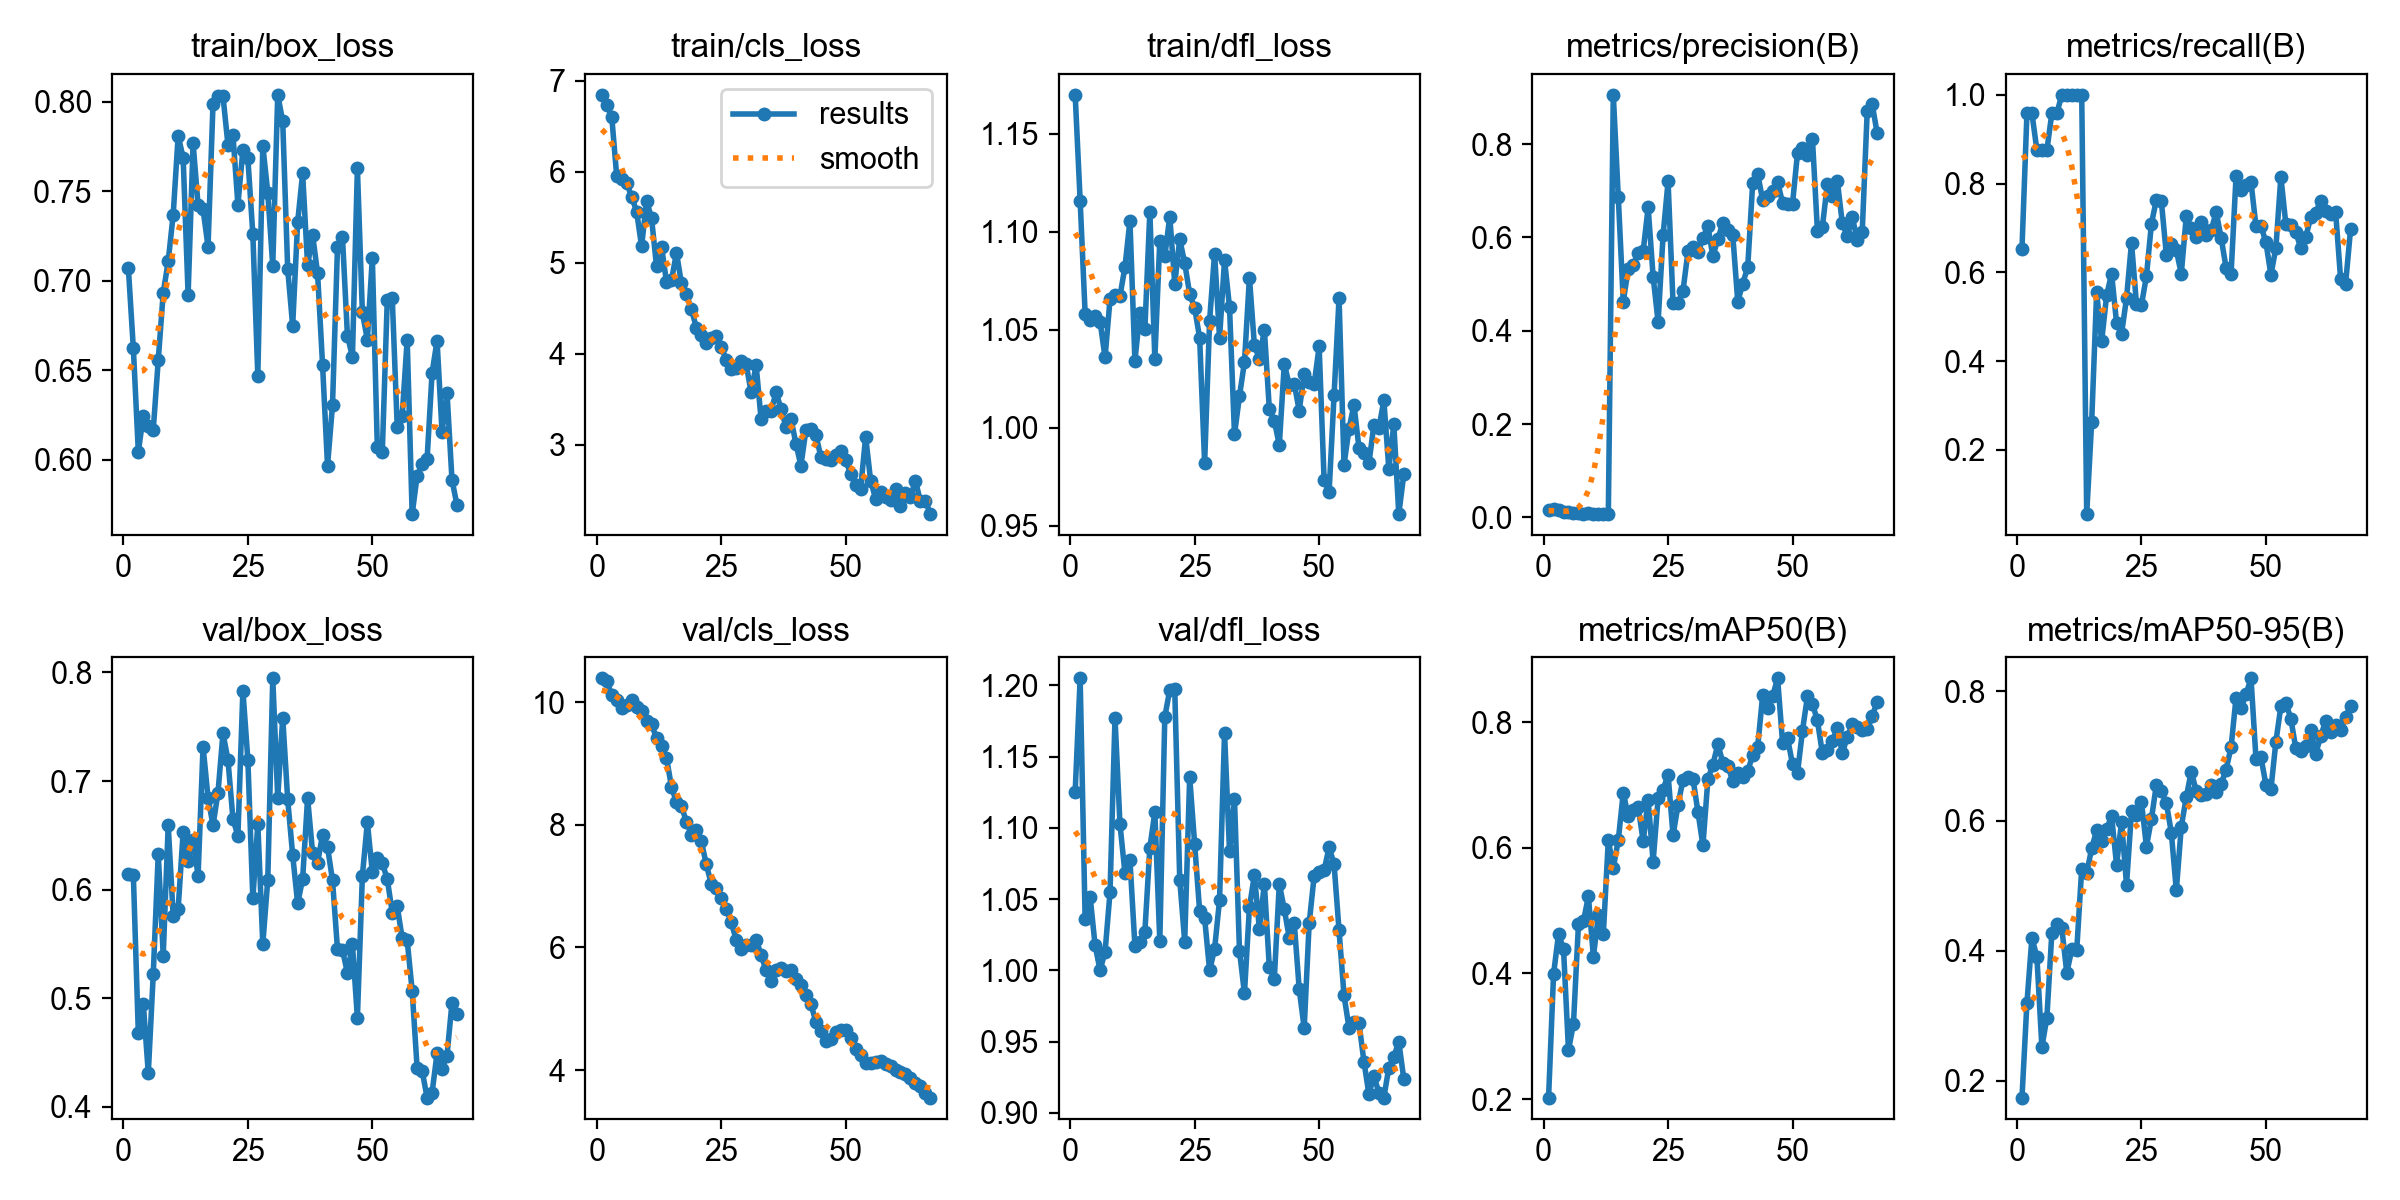


confusion_matrix.png:


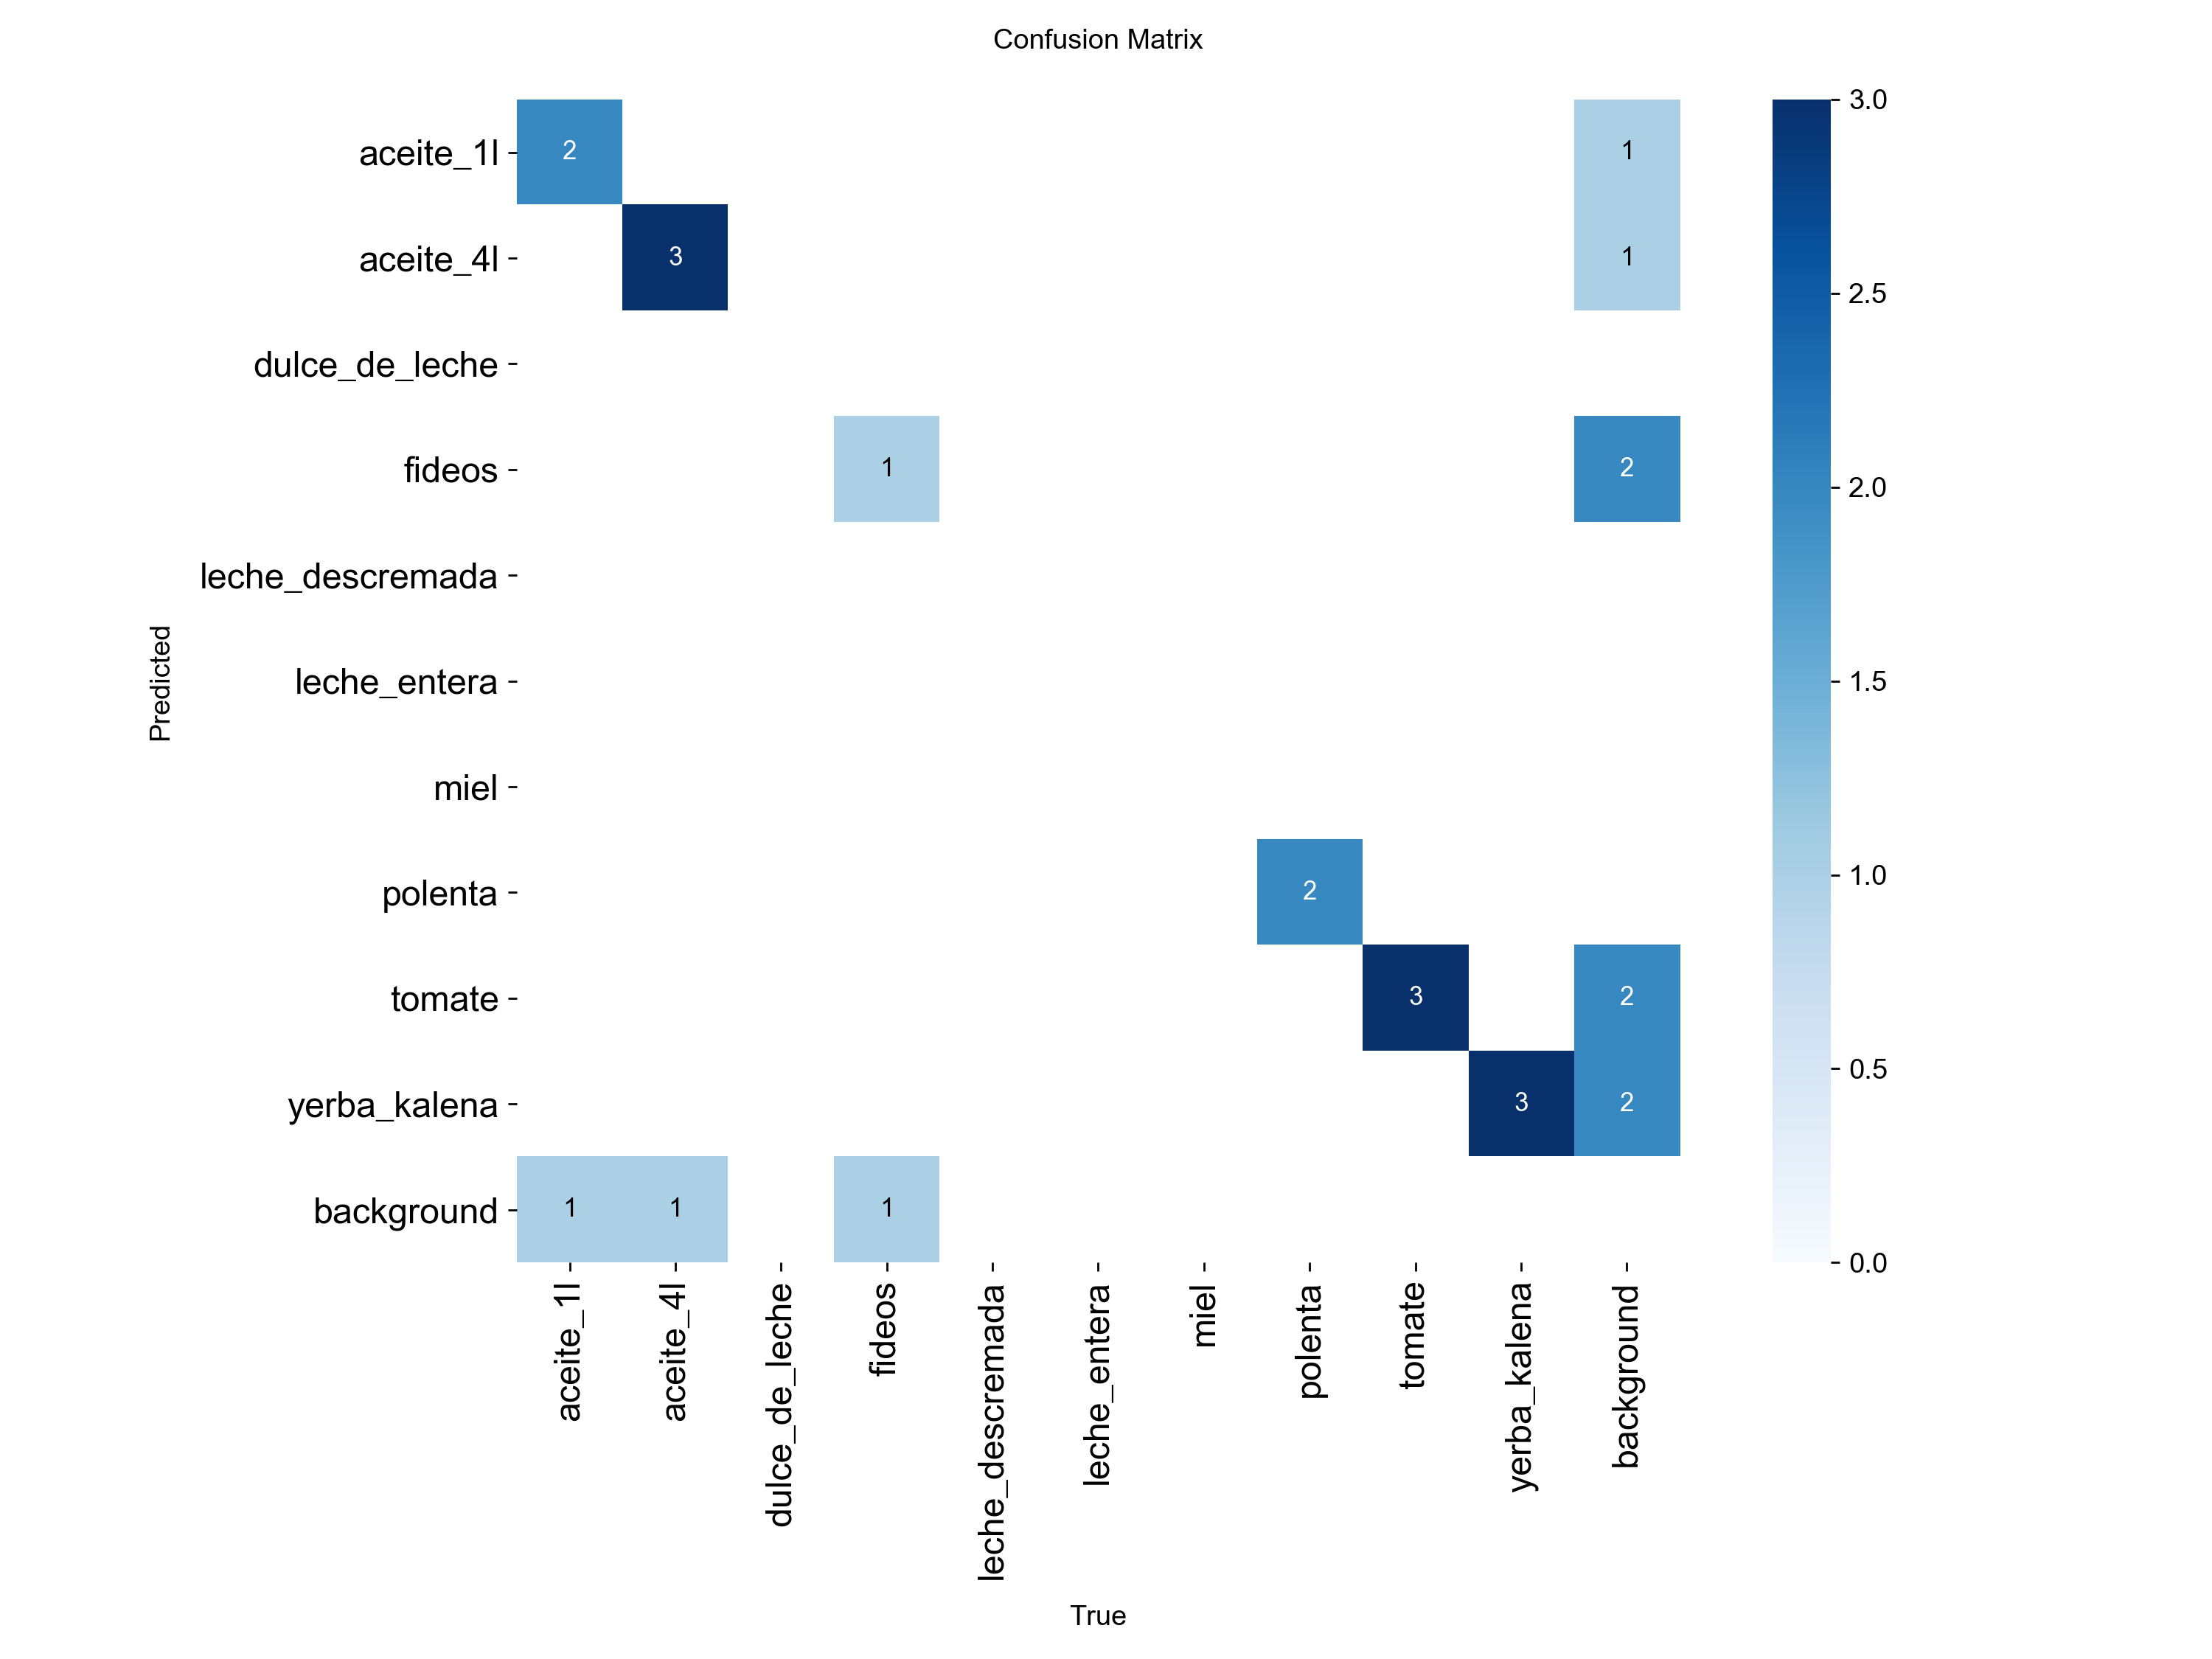

In [16]:
from IPython.display import Image, display

results_dir = Path(PROJECT) / NAME

# Mostrar curvas si existen
for plot_name in ["results.png", "confusion_matrix.png", "PR_curve.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        print(f"\n{plot_name}:")
        display(Image(filename=str(plot_path)))

## Validación

In [17]:
# Cargar el mejor modelo y validar
best_model = YOLO(str(best_model_path))
val_results = best_model.val(data=str(DATA_YAML))

Ultralytics 8.4.26 🚀 Python-3.14.3 torch-2.11.0 CPU (Apple M4 Pro)
YOLOv10n summary (fused): 102 layers, 2,267,118 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 663.4±300.1 MB/s, size: 55.5 KB)
val: Scanning /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases/val/labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 10.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all         13         17       0.72      0.803       0.87       0.82
             aceite_1l          3          3      0.855      0.667      0.913      0.894
             aceite_4l          3          4      0.632       0.75      0.745      0.666
                fideos          1          2      0.349        0.5      0.578      0.534
               polenta          2          2          1      0.904      0.995      0.962
 

## Prueba rápida de inferencia

In [18]:
# Probar con una imagen de validación
if val_images:
    test_image = val_images[0]
    print(f"Probando con: {test_image}")
    
    results = best_model.predict(source=str(test_image), conf=0.5)
    
    # Mostrar resultado
    for r in results:
        im_array = r.plot()
        display(Image(data=im_array))

Probando con: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases/val/images/IMG_3096_jpg.rf.15c526f48d040d6a4578972372964039.jpg

image 1/1 /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_10_clases/val/images/IMG_3096_jpg.rf.15c526f48d040d6a4578972372964039.jpg: 640x640 (no detections), 56.1ms
Speed: 0.7ms preprocess, 56.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


## Copiar modelo a models/

In [19]:
import shutil

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

dest_path = models_dir / "best.pt"
shutil.copy(best_model_path, dest_path)
print(f"Modelo copiado a: {dest_path}")

Modelo copiado a: ../models/best.pt


## Test en imágenes multi-producto

Probamos el modelo entrenado con imágenes individuales en escenas con múltiples productos.

In [ ]:
# Verificar si existen imágenes multi-producto
multi_product_dir = Path("../data/jpg/varios_productos")

if multi_product_dir.exists():
    multi_images = list(multi_product_dir.glob("*.jpg"))
    print(f"Imágenes multi-producto encontradas: {len(multi_images)}")
else:
    print("No se encontró el directorio de imágenes multi-producto")
    print("Para crear este directorio:")
    print("  1. Tomar fotos con múltiples productos en la mesa")
    print("  2. Guardar en data/heic/varios_productos/")
    print("  3. Ejecutar: uv run python src/convert_heic.py")
    multi_images = []

In [ ]:
# Ejecutar inferencia en imágenes multi-producto
if multi_images:
    print("Ejecutando inferencia en imágenes multi-producto...\n")
    
    detections_count = 0
    no_detections_count = 0
    
    for img_path in multi_images[:10]:  # Mostrar primeras 10
        results = best_model.predict(source=str(img_path), conf=0.5, verbose=False)
        
        for r in results:
            n_detections = len(r.boxes)
            if n_detections > 0:
                detections_count += 1
                classes = [r.names[int(c)] for c in r.boxes.cls]
                print(f"✓ {img_path.name}: {', '.join(classes)}")
            else:
                no_detections_count += 1
                print(f"✗ {img_path.name}: Sin detecciones")
    
    # Resumen
    total = detections_count + no_detections_count
    print(f"\n{'='*50}")
    print(f"RESUMEN (primeras {total} imágenes):")
    print(f"  Con detecciones: {detections_count}/{total} ({100*detections_count/total:.1f}%)")
    print(f"  Sin detecciones: {no_detections_count}/{total} ({100*no_detections_count/total:.1f}%)")

In [ ]:
# Mostrar ejemplos de detecciones en multi-producto
if multi_images:
    print("Ejemplos de inferencia en imágenes multi-producto:\n")
    
    # Mostrar 4 imágenes
    for i, img_path in enumerate(multi_images[:4]):
        results = best_model.predict(source=str(img_path), conf=0.5, verbose=False)
        
        print(f"\nImagen {i+1}: {img_path.name}")
        for r in results:
            # Convertir resultado a imagen
            img_with_boxes = r.plot()
            
            # Convertir BGR a RGB para mostrar
            from PIL import Image as PILImage
            import io
            
            pil_img = PILImage.fromarray(img_with_boxes[..., ::-1])
            
            # Redimensionar para visualización
            pil_img.thumbnail((600, 600))
            
            # Guardar en buffer y mostrar
            buf = io.BytesIO()
            pil_img.save(buf, format='JPEG')
            buf.seek(0)
            display(Image(data=buf.read()))

## Conclusión POC

El modelo entrenado con imágenes de producto individual tiene buen rendimiento en validación (mAP50 > 0.70), pero no generaliza bien a escenas multi-producto.

Para mejorar el rendimiento en escenas reales:
1. Anotar las imágenes multi-producto en Roboflow
2. Combinar con el dataset actual
3. Reentrenar el modelo

Ver notebook: `train_multi_and_single_product.ipynb`